# Prediction overlap: static and dynamic FER

Self-contained paper-figure notebook for the image-based and FEA-based baselines on EmoHeVRDB. All plotting counts are embedded below; no repository, CSV, model, or network access is required.

Run all cells in order. Requirements: Python 3, NumPy, Matplotlib, and Seaborn (plus Jupyter to open the notebook). The two figures are displayed separately and exported as PDF and PNG to `figures/`. Figure labels are in English; settings can be adjusted in the shared style cell or separately for each figure.

## Definitions and counting unit

Columns represent **ground-truth emotion classes**. Rows represent **both correct**, **only FEA correct**, **only image correct**, and **both wrong**. “Both wrong” does not require the models to predict the same wrong label.

Central and Side views are pooled: **108 view-level comparisons per class, 756 in total, from 378 reenactments**. Each reenactment's FEA prediction is paired with each of its two image-view predictions. These are descriptive counts, not 756 independent reenactments. Percentages are calculated within each class and sum to 100% before rounding.

## Sources and reconciliation

- **SFER:** counts copied without changes from the supplied `sfer_prediction_overlap (2).py`.
- **DFER:** calculated from `emohevrdb-dfer/6_discussion/significance-tests/dynamic-significance-tests/dynamic_test_predictions.csv` in `2026-09-21-4-emohevrdb-dfer.zip`. Correctness is `image_pred_id == true_label_id` and `fea_pred_id == true_label_id`; all Central/Side test rows are included.
- CSV SHA-256: `0e9d30b42bf7ea5fce8fa75cf83f224db0a383b992a99c68f7a8fc10cfc36045`.
- Source checks: 756 unique sample IDs, 378 reenactments with two rows each, a consistent FEA prediction within each reenactment, and 108 rows per class.
- **Historical comparison:** Fig. 6, p. 9 of `20260921_wip_IEEE_TAFFC_emoji_hero_vr.pdf` differs from the current CSV. Its bars were checked visually and pooled across Central/Side. The notebook uses the current CSV for the DFER figure; the historical counts below are retained only for the comparison.


In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

print(f"NumPy {np.__version__}; Matplotlib {matplotlib.__version__}; Seaborn {sns.__version__}")

NumPy 1.26.4; Matplotlib 3.9.4; Seaborn 0.13.2


In [2]:
CLASSES = ["Anger", "Disgust", "Fear", "Happiness", "Neutral", "Sadness", "Surprise"]
ROW_NAMES = ["Both correct", "Only FEA correct", "Only image correct", "Both wrong"]

SFER_COUNTS = np.array([
    [33, 49, 40, 92, 70, 50, 80],
    [19, 17, 22, 14, 20, 22, 14],
    [22, 25, 28,  1, 11, 17, 10],
    [34, 17, 18,  1,  7, 19,  4],
], dtype=int)

DFER_COUNTS = np.array([
    [40, 51, 47, 99, 75, 79, 85],
    [16,  9, 19,  9, 27, 17, 19],
    [10, 23, 24,  0,  6,  9,  2],
    [42, 25, 18,  0,  0,  3,  2],
], dtype=int)

# Historical Fig. 6: for reconciliation only, not used for plotting.
DFER_FIG6_COUNTS = np.array([
    [40, 51, 47, 99, 73, 80, 85],
    [16, 11, 17,  9, 27, 18, 19],
    [10, 23, 24,  0,  8,  8,  2],
    [42, 23, 20,  0,  0,  2,  2],
], dtype=int)

for name, counts in [("SFER", SFER_COUNTS), ("DFER", DFER_COUNTS), ("DFER Fig. 6", DFER_FIG6_COUNTS)]:
    assert counts.shape == (4, 7)
    assert np.issubdtype(counts.dtype, np.integer) and (counts >= 0).all()
    np.testing.assert_array_equal(counts.sum(axis=0), np.full(7, 108))
    assert counts.sum() == 756
    print(f"{name}: {counts.sum()} comparisons; row totals {counts.sum(axis=1).tolist()}")

print("\nDFER differences (current CSV minus historical Fig. 6):")
for j, emotion in enumerate(CLASSES):
    delta = DFER_COUNTS[:, j] - DFER_FIG6_COUNTS[:, j]
    if np.any(delta):
        print(f"{emotion}: " + ", ".join(f"{label}: {int(value):+d}" for label, value in zip(ROW_NAMES, delta)))

SFER: 756 comparisons; row totals [414, 128, 114, 100]
DFER: 756 comparisons; row totals [476, 116, 74, 90]
DFER Fig. 6: 756 comparisons; row totals [475, 117, 75, 89]

DFER differences (current CSV minus historical Fig. 6):
Disgust: Both correct: +0, Only FEA correct: -2, Only image correct: +0, Both wrong: +2
Fear: Both correct: +0, Only FEA correct: +2, Only image correct: +0, Both wrong: -2
Neutral: Both correct: +2, Only FEA correct: +0, Only image correct: -2, Both wrong: +0
Sadness: Both correct: -1, Only FEA correct: -1, Only image correct: +1, Both wrong: +1


## Shared figure settings

The layout follows the supplied SFER script: blue heatmap, bold counts, smaller percentages, automatic text contrast, and no colorbar. **The default color range is fixed at 0–100% for both figures**, so the same color means the same proportion. Set `color_max=None` to reproduce the original script's separate per-figure scaling. Font sizes, labels, text positions, cell geometry, and export settings are configurable below.

The default 13 × 6 inch canvas preserves the supplied design; adjust it and the fonts together for the intended paper width. No figure titles are added by default, allowing captions/panel labels to be handled in LaTeX.

In [3]:
STYLE = dict(
    figsize=(13, 6),  # Figure width and height in inches.
    outcomes=["Both\ncorrect", "Only\nFEA\ncorrect", "Only\nimage\ncorrect", "Both\nwrong"],  # Row labels; \n inserts line breaks.
    tick_size=20,  # Font size of row and column labels in points.
    tick_weight="bold",  # Font weight of row and column labels.
    count_size=30,  # Font size of cell counts in points.
    percent_size=20,  # Font size of cell percentages in points.
    percent_decimals=2,  # Number of decimal places shown for percentages.
    count_y=0.4,  # Vertical count position within each cell: 0 = top, 1 = bottom.
    percent_y=0.72,  # Vertical percentage position within each cell: 0 = top, 1 = bottom.
    color_max=92,  # Color-scale maximum in percent; None uses each plot's maximum, 100 fixes the scale.
    end_color="#04092e",  # Color at the upper end of the blue color scale.
    square=False,  # If True, enforce square heatmap cells.
    linewidths=2,  # Width of the white lines separating cells in points.
    tick_length=6,  # Length of axis tick marks in points.
    tick_width=2,  # Width of axis tick marks in points.
    tick_pad=6,  # Distance between tick marks and their labels in points.
    label_linespacing=1.15,  # Line-spacing factor for multiline row labels.
    layout_pad=0.6,  # Padding around the figure as a fraction of the default font size.
    font_family="DejaVu Sans",  # Font family used throughout the figure.
    title=None,  # Optional figure title; None omits the title.
)

EXPORT_DIR = Path("figures/overlaps")  # Output directory, relative to the notebook's working directory.
EXPORT_FORMATS = ("pdf", "png")  # File formats to export; optionally add "svg".
EXPORT_DPI = 400  # Resolution in dots per inch for PNG and rasterized elements.
EXPORT_PAD_INCHES = 0.02  # Extra margin around the tightly cropped export, in inches.
SAVE_FIGURES = True  # If True, save the figures; if False, only display them.

In [4]:
def plot_prediction_overlap(counts, style):
    """Plot the four correctness groups; percentages are normalized by class."""
    counts = np.asarray(counts)
    if counts.shape != (4, len(CLASSES)) or not np.isfinite(counts).all():
        raise ValueError("Expected a finite 4 × 7 count matrix.")
    if np.any(counts < 0) or np.any(counts != np.floor(counts)) or np.any(counts.sum(axis=0) == 0):
        raise ValueError("Counts must be nonnegative integers with positive column totals.")
    percentages = 100 * counts / counts.sum(axis=0)
    vmax = percentages.max() if style["color_max"] is None else style["color_max"]
    if vmax <= 0 or vmax < percentages.max():
        raise ValueError("color_max must cover every cell percentage.")
    blues = plt.get_cmap("Blues")
    stops = [(x * 0.88, blues(x)) for x in np.linspace(0, 1, 12)]
    cmap = LinearSegmentedColormap.from_list("extended_blues", stops + [(1, style["end_color"])])
    norm = Normalize(0, vmax)
    with plt.rc_context({"font.family": style["font_family"], "pdf.fonttype": 42,
                         "ps.fonttype": 42, "svg.fonttype": "none"}):
        fig, ax = plt.subplots(figsize=style["figsize"])
        sns.heatmap(percentages, ax=ax, cmap=cmap, norm=norm, cbar=False,
                    square=style["square"], xticklabels=CLASSES,
                    yticklabels=style["outcomes"], linewidths=style["linewidths"], linecolor="white")
        for (row, col), count in np.ndenumerate(counts):
            # rgb = np.array(cmap(norm(percentages[row, col]))[:3])
            # linear = np.where(rgb <= 0.04045, rgb / 12.92, ((rgb + 0.055) / 1.055) ** 2.4)
            # color = "#ffffff" if linear @ [0.2126, 0.7152, 0.0722] < 0.179 else "#000000"
            color = "white" if percentages[row, col] > 50 else "black"
            ax.text(col + 0.5, row + style["count_y"], str(int(count)),
                    ha="center", va="center", fontsize=style["count_size"], fontweight="bold", color=color)
            ax.text(col + 0.5, row + style["percent_y"],
                    f"{percentages[row, col]:.{style['percent_decimals']}f}%",
                    ha="center", va="center", fontsize=style["percent_size"], color=color)
        ax.set_xticklabels(CLASSES, rotation=0, fontsize=style["tick_size"], fontweight=style["tick_weight"])
        ax.set_yticklabels(style["outcomes"], rotation=0, fontsize=style["tick_size"],
                           fontweight=style["tick_weight"], va="center", linespacing=style["label_linespacing"])
        ax.tick_params(axis="both", length=style["tick_length"], width=style["tick_width"], pad=style["tick_pad"])
        if style["title"]:
            ax.set_title(style["title"], fontsize=style["tick_size"], pad=12)
        fig.tight_layout(pad=style["layout_pad"])
    return fig, ax


def export_figure(fig, stem):
    """Export to the configured directory; reruns replace files with the same name."""
    if not SAVE_FIGURES:
        return
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    with plt.rc_context({"pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none"}):
        for extension in EXPORT_FORMATS:
            path = EXPORT_DIR / f"{stem}.{extension}"
            fig.savefig(path, dpi=EXPORT_DPI, bbox_inches="tight", pad_inches=EXPORT_PAD_INCHES)
            print(path)


## SFER overlap

Adjust this figure independently by adding overrides to its style dictionary, e.g. `count_size=28`. Rerun this cell after changing shared settings or the plot function.

figures/overlaps/sfer_prediction_overlap.pdf
figures/overlaps/sfer_prediction_overlap.png


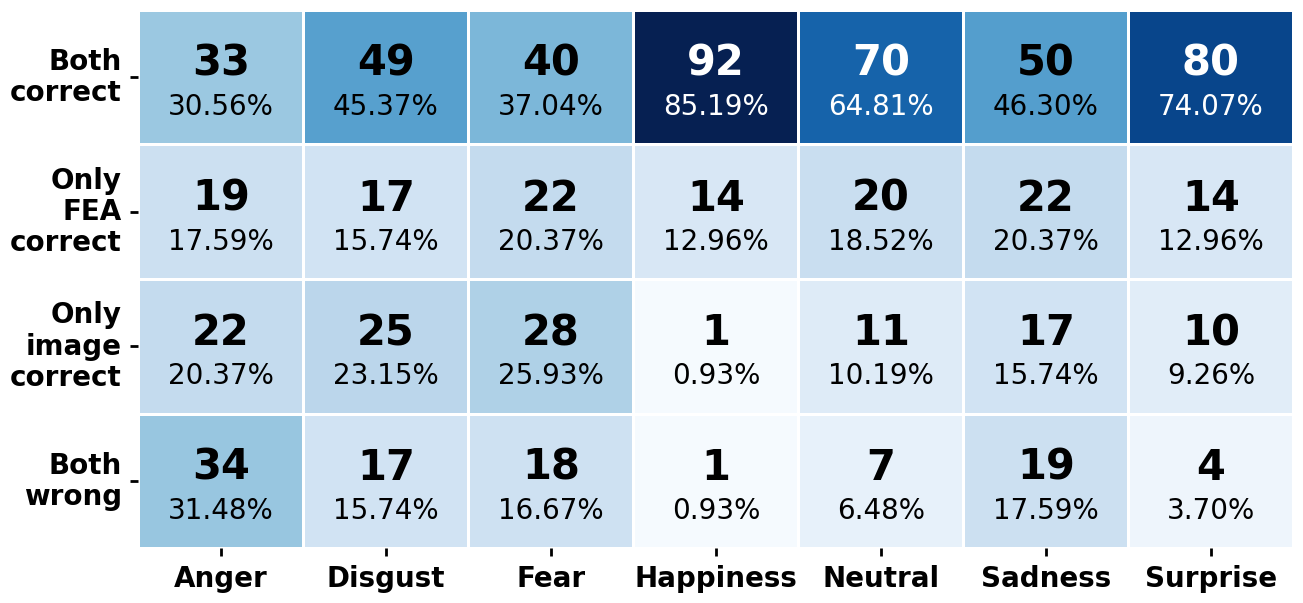

In [5]:
sfer_style = dict(STYLE)  # Example: dict(STYLE, count_size=28)
fig_sfer, ax_sfer = plot_prediction_overlap(SFER_COUNTS, sfer_style)
export_figure(fig_sfer, "sfer_prediction_overlap")
plt.show()
plt.close(fig_sfer)

## DFER overlap

Adjust this figure independently by adding overrides to its style dictionary, e.g. `count_size=28`. Rerun this cell after changing shared settings or the plot function.

figures/overlaps/dfer_prediction_overlap.pdf
figures/overlaps/dfer_prediction_overlap.png


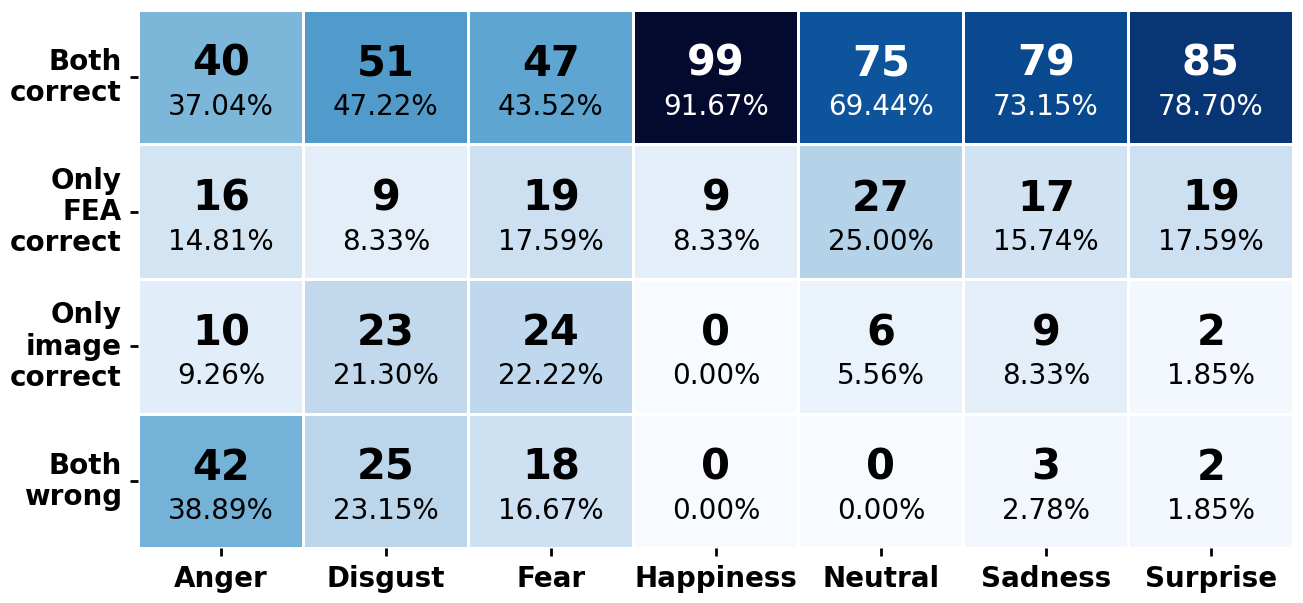

In [6]:
dfer_style = dict(STYLE)  # Example: dict(STYLE, count_size=28)
fig_dfer, ax_dfer = plot_prediction_overlap(DFER_COUNTS, dfer_style)
export_figure(fig_dfer, "dfer_prediction_overlap")
plt.show()
plt.close(fig_dfer)

## DFER aggregation recipe (documentation only)

The embedded DFER matrix was obtained with the following logic. This snippet is not executed and is not required to generate the figures:

```python
predictions = pd.read_csv("dynamic_test_predictions.csv")
image_correct = predictions.image_pred_id.eq(predictions.true_label_id)
fea_correct = predictions.fea_pred_id.eq(predictions.true_label_id)
groups = [image_correct & fea_correct,
          ~image_correct & fea_correct,
          image_correct & ~fea_correct,
          ~image_correct & ~fea_correct]
counts = np.array([
    [(mask & predictions.true_label.eq(emotion)).sum() for emotion in CLASSES]
    for mask in groups
], dtype=int)
```

With the current CSV, image accuracy is 550/756 = 72.75% and FEA accuracy is 592/756 = 78.31% (equivalently 296/378 reenactments). At least one model is correct for 666/756 = 88.10%; this is descriptive prediction-selection coverage, not a strict ceiling on learned multimodal fusion. The older WIP reports 88.23% from its historical overlap counts.
